In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

import os
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error

from swimnetworks import (Dense, Linear)

filepath = './hyperparameter_study/'

(2000, 1) (2000, 1)


Text(0, 0.5, 'Test functions')

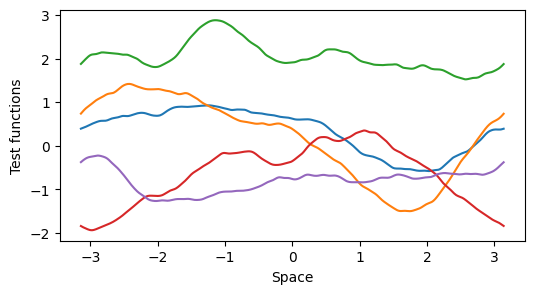

In [2]:
random_state = 1 # notebook wide random state
n_points = 1000 # total number of data points
data_smoothness = 2 # smoothness of the test functions. 0 is "very rough", 2 is "quite smooth".
data_test_size = 1000
n_fourier_coeff = 50 # number of fourier modes to ues in random test functions

def test_function(x, n_coeff=100, smoothness=1, _random_state=1):
    rng = np.random.default_rng(_random_state)
    coeff = rng.uniform(low=np.min(x), high=np.max(x), size=(n_coeff, 2))
    coeff[:, 0] = np.sort(coeff[:, 0])
    y = np.zeros_like(x)
    for k in range(n_coeff-1):
        y[(x < coeff[k, 0]) & (np.abs(y) == 0)] = coeff[k, 1]
    for s in range(smoothness):
        y = y - np.mean(y, keepdims=True)
        y = y / np.std(y, keepdims=True)
        y = np.cumsum(y.reshape((-1, )) * np.gradient(x.reshape((-1, ))))
    return y
    

def test_function(x, n_coeff=100, smoothness=1.0, _random_state=1):
    rng = np.random.default_rng(_random_state)
    coeff = rng.normal(loc=0, scale=1, size=(n_coeff, 2))
    return np.sum([
        1 / (k**smoothness + 1) * (coeff[k, 0] * np.cos(x * k) + coeff[k, 1] * np.sin(x * k))
        for k in range(n_coeff)
    ], axis=0)
    
rng = np.random.default_rng(random_state)
xlim = [-np.pi, np.pi]
data_input_test = np.linspace(xlim[0], xlim[1], data_test_size).reshape((-1, 1)) # useful to compute proper l2 error
data_input = np.sort(rng.uniform(low=xlim[0], high=xlim[1], size=(n_points + data_test_size, 1)), axis=0)
data_output = test_function(data_input, n_coeff=n_fourier_coeff, smoothness=data_smoothness, _random_state=random_state)
data_output_test = test_function(data_input_test, n_coeff=n_fourier_coeff, smoothness=data_smoothness, _random_state=random_state)

print(data_input.shape, data_output.shape)

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
for k in range(5):
    ax.plot(data_input, test_function(data_input,n_coeff=n_fourier_coeff, smoothness=data_smoothness, _random_state=1 + k))
ax.set_xlabel('Space')
ax.set_ylabel('Test functions')

1.400347263562698e-10


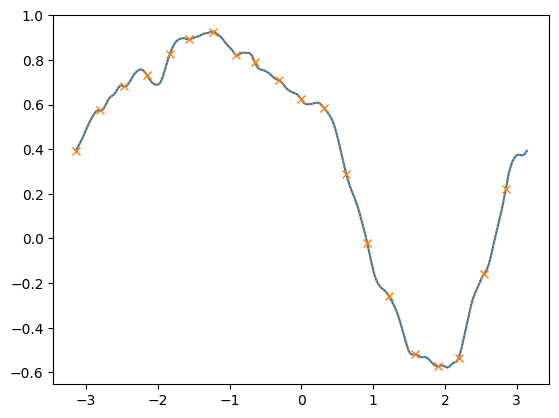

In [3]:
def to_circle(angle):
    return angle # np.column_stack([np.cos(angle), np.sin(angle)]) # 

def l2_relative_error(f_true, f_approx):
    l2_true = np.linalg.norm(f_true, ord=2)
    l2_approx = np.linalg.norm(f_true - f_approx, ord=2)
    return l2_approx / l2_true

def test_error_at_width(n_width, n_layers, _data_in, _data_out, _data_out_test, activation='tanh', _random_state=1):
    if activation == 'relu':
        activation_function = 'relu'
        weight_sampling = 'relu'
    elif activation == 'tanh':
        activation_function = 'tanh'
        weight_sampling = 'tanh'

    steps = []
    for l in range(n_layers):
        steps.append((f"fcn{l+1}", Dense(layer_width=n_width,
                                           activation=activation_function,
                                           parameter_sampler=weight_sampling,
                                           random_seed=_random_state)))
        _random_state += 1
    steps.append(("lin", Linear(regularization_scale=1e-16)))
    model = Pipeline(steps=steps, )

    # setup the training and test data
    # train the model
    model.fit(to_circle(_data_in), _data_out)
    # return test error
    return l2_relative_error(_data_out_test, model.predict(to_circle(data_input_test))), model

_e, _m = test_error_at_width(16000, 1, data_input, data_output, data_output_test, activation='tanh', _random_state=123)

print(_e)

fig, ax = plt.subplots(1, 1)
ax.plot(data_input, data_output)
ax.plot(data_input, _m.predict(to_circle(data_input)), 'x:', linewidth=1, markevery=100)

In [4]:
# see how the error decreases with increasing width
n_layers = [1]
n_widths = (2**np.linspace(np.log(100) / np.log(2), np.log(16000) / np.log(2), 10)).astype(np.int32)
errors = []
n_tests = 5
n_random_states = 5

data_random_state = 1
for layers in n_layers:
    for width in n_widths:
        for random_state in np.arange(1, n_random_states+1):
            error_mean = []
            for i_function in range(n_tests):
                _data_output = test_function(data_input, n_coeff=n_fourier_coeff, smoothness=data_smoothness, _random_state=data_random_state + i_function)
                _data_output_test = test_function(data_input_test, n_coeff=n_fourier_coeff, smoothness=data_smoothness, _random_state=data_random_state + i_function)
                error_, _ = test_error_at_width(width, layers, data_input, _data_output, _data_output_test, activation='tanh', _random_state=random_state+1+i_function*123)
                error_mean.append(error_)
            experiment = {
                'n_width': width,
                'n_layers': layers,
                'l2_mean': np.mean(error_mean),
                'l2_std': np.std(error_mean),
                'l2_min': np.min(error_mean),
                'l2_max': np.max(error_mean),
                'random_state': random_state
            }
            errors.append(experiment)
            print(f'Error at {width} neurons, layers {layers}: {np.mean(error_mean):.15f}')

errors_fd = pd.DataFrame.from_dict(errors)
errors_fd.to_csv(os.path.join(filepath, 'experiment_illustration_2.csv'))

Error at 100 neurons, layers 1: 0.004370994017902
Error at 100 neurons, layers 1: 0.004638296947375
Error at 100 neurons, layers 1: 0.006200365520262
Error at 100 neurons, layers 1: 0.005677733271905
Error at 100 neurons, layers 1: 0.004260301027197
Error at 175 neurons, layers 1: 0.003569692480980
Error at 175 neurons, layers 1: 0.002637741112131
Error at 175 neurons, layers 1: 0.003078788212260
Error at 175 neurons, layers 1: 0.002057263689295
Error at 175 neurons, layers 1: 0.002388695061686
Error at 308 neurons, layers 1: 0.001268650311990
Error at 308 neurons, layers 1: 0.001447723414167
Error at 308 neurons, layers 1: 0.001468814646370
Error at 308 neurons, layers 1: 0.001414025372575
Error at 308 neurons, layers 1: 0.001554011674781
Error at 542 neurons, layers 1: 0.000534116274604
Error at 542 neurons, layers 1: 0.000500189524181
Error at 542 neurons, layers 1: 0.000622075414229
Error at 542 neurons, layers 1: 0.000658997506809
Error at 542 neurons, layers 1: 0.000542280545900


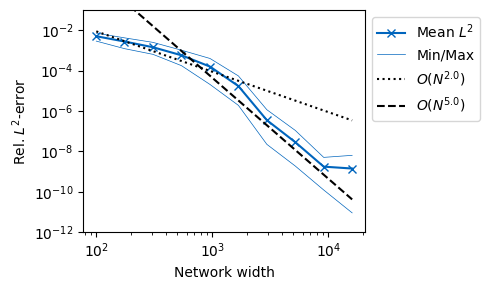

In [6]:
df = pd.read_csv(os.path.join(filepath, 'experiment_illustration_2.csv'))
errors = df.to_numpy()

# To get unique values in one series/column
widths = df['n_width'].unique()
avg_values = df.groupby(['n_width']).mean()
l2_mean = avg_values['l2_mean']
l2_min = avg_values['l2_min']
l2_max = avg_values['l2_max']
fig, ax = plt.subplots(1, 1, figsize=(5, 3))

sample_blue = (0.0, 101.0 / 255.0, 189.0 / 255.0)

ax.loglog(widths, avg_values['l2_mean'], 'x-', color=sample_blue, label=fr'Mean $L^2$')#, label=f'Mean $L^2$'
ax.loglog(widths, avg_values['l2_min'], '-', linewidth=.5, color=sample_blue, label=f'Min/Max')#, label=f'Min $L^2$'
ax.loglog(widths, avg_values['l2_max'], '-', linewidth=.5, color=sample_blue, label=None)#, label=f'Max $L^2$'

# convergence with different rates
conv_rates = [2.]
for cr in conv_rates:
    ax.loglog(widths, 1e-0 * 1/(widths)**cr * (0.008735147361538681 / (1/(widths[0])**cr)), ':', color='black', label=fr'$O(N^{{{cr}}})$')

cr = 5.
ax.loglog(widths, 5e2* 1/(widths)**cr * (0.008735147361538681 / (1/(widths[0])**cr)), '--', color='black', label=fr'$O(N^{{{cr}}})$')

ax.set_ylim([1e-12, 1e-1])
labels = ['Mean $L^2$', 'Min $L^2$', 'Max $L^2$', '$O(N^{{{2}}})$']#, '$O(N^{{{0.5}}})$', '$O(N^{{{1}}})$']

ax.set_xlabel('Network width')
ax.set_ylabel(f'Rel. $L^2$-error')
ax.legend(bbox_to_anchor=(1,1), loc="upper left")

fig.tight_layout()

os.makedirs(os.path.join(filepath, 'figures'), exist_ok=True)
fig.savefig(os.path.join(filepath, 'figures', 'illustration_2_figure.pdf'))
fig.savefig(os.path.join(filepath, 'figures', 'illustration_2_figure.png'))